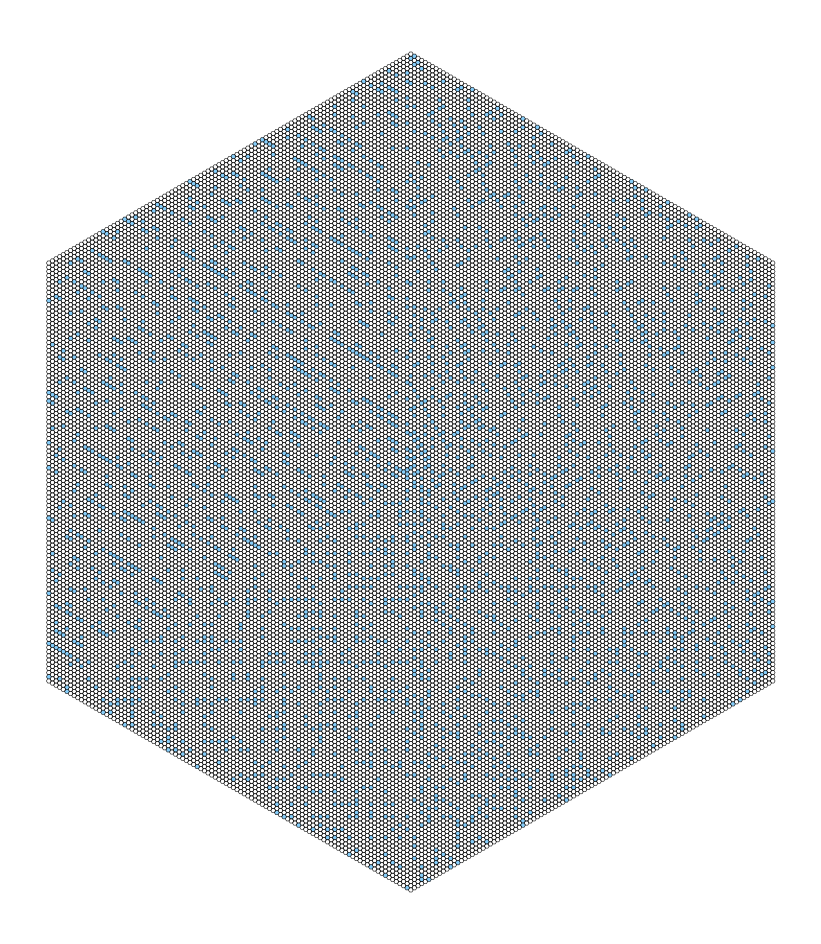

In [12]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    r = int(math.sqrt(n))
    for i in range(3, r+1, 2):
        if n % i == 0:
            return False
    return True

def axial_to_xy(q, r, size):
    x = size * (3/2 * q)
    y = size * (math.sqrt(3)/2 * (2*r + q))
    return x, y

def hex_corners(x, y, size):
    return [
        (x + size * math.cos(math.radians(60*i)),
         y + size * math.sin(math.radians(60*i)))
        for i in range(6)
    ]

def generate_hex_spiral(n_layers):
    dirs = [(1,0), (1,-1), (0,-1), (-1,0), (-1,1), (0,1)]
    coords = [(0,0)]

    for layer in range(1, n_layers+1):
        q, r = -layer, layer
        for d in range(6):
            dq, dr = dirs[d]
            for _ in range(layer):
                coords.append((q, r))
                q += dq
                r += dr
    return coords

def draw_hex_spiral(n_layers=100, size=2):   # ★ 레이어 크게, 육각형은 작게
    coords = generate_hex_spiral(n_layers)

    fig, ax = plt.subplots(figsize=(12, 12))

    for num, (q, r) in enumerate(coords, start=1):
        x, y = axial_to_xy(q, r, size)
        corners = hex_corners(x, y, size)

        face = "lightskyblue" if is_prime(num) else "none"

        poly = Polygon(
            corners, closed=True,
            edgecolor='black',
            facecolor=face,
            linewidth=0.4
        )
        ax.add_patch(poly)

        # 너무 많으면 숫자는 과하게 복잡해지므로 표시 제거 옵션
        # 필요하면 아래 한 줄 주석 해제
        # ax.text(x, y, str(num), ha='center', va='center', fontsize=4)

    ax.set_aspect('equal')
    ax.autoscale_view()
    ax.axis("off")

    plt.show()

draw_hex_spiral()
